In [132]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable


orders = pd.read_csv("bootcamp_orders.csv", parse_dates=["order_date"])
orders["order_date"].dtype

In [133]:
import pandas as pd

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/1380554432.py:5: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])


,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
0,2018,11500,강서구,10300,화곡동,1.0,대지,1159.0,0.0,"우장산아이파크,이편한세상",...,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN,NaN
1,2018,11410,서대문구,11200,대현동,1.0,대지,144.0,0.0,럭키대현,...,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN,NaN
2,2018,11590,동작구,10700,사당동,1.0,대지,169.0,32.0,현대,...,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN,NaN
3,2018,11350,노원구,10500,상계동,1.0,대지,1380.0,4.0,초산빌라,...,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN,NaN
4,2018,11380,은평구,11000,증산동,1.0,대지,189.0,63.0,궁전맨션(189-63),...,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833610,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833611,2024,11530,구로구,10700,개봉동,1.0,대지,170.0,33.0,금석연립(170-33),...,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래,서울 강남구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [134]:
df['신고구분'].info() 
''' 
RangeIndex: 833614 entries, 0 to 833613
225344 non-null  object
'''

<class 'pandas.core.series.Series'>
RangeIndex: 833614 entries, 0 to 833613
Series name: 신고구분
Non-Null Count   Dtype 
--------------   ----- 
225344 non-null  object
dtypes: object(1)
memory usage: 6.4+ MB


' \nRangeIndex: 833614 entries, 0 to 833613\n225344 non-null  object\n'

In [135]:
df['신고구분'].isnull().sum() / len(df)
# np.float64(0.7296782443672971)

np.float64(0.7296782443672971)

In [136]:
df['신고구분'].value_counts()

신고구분
중개거래    184042
직거래      41302
Name: count, dtype: int64

In [137]:
df['신고한_개업공인중개사_시군구명'].isnull().sum() / len(df)
# np.float64(0.7793751064641429)

np.float64(0.7793751064641429)

In [138]:
import pandas as pd

# 1. 파일 불러오기 (인코딩은 상황에 맞게 'euc-kr' 또는 'utf-8' 선택)
# 구글 시트에서 저장한 파일이라면 보통 'utf-8'입니다.
df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])

# 2. 변경할 컬럼 매핑 딕셔너리 생성
# { "기존 한글명": "변경할 영어명" }
rename_dict = {
    "접수연도": "RCPT_YR",
    "자치구코드": "CGG_CD",
    "자치구명": "CGG_NM",
    "법정동코드": "STDG_CD",
    "법정동명": "STDG_NM",
    "지번구분": "LOTNO_SE",
    "지번구분명": "LOTNO_SE_NM",
    "본번": "MNO",
    "부번": "SNO",
    "건물명": "BLDG_NM",
    "계약일": "CTRT_DAY",
    "물건금액(만원)": "THING_AMT",
    "건물면적(㎡)": "ARCH_AREA",
    "토지면적(㎡)": "LAND_AREA",
    "층": "FLR",
    "권리구분": "RGHT_SE",
    "취소일": "RTRCN_DAY",
    "건축년도": "ARCH_YR",
    "건물용도": "BLDG_USG",
    "신고구분": "DCLR_SE",
    "신고한_개업공인중개사_시군구명": "OPBIZ_RESTAGNT_SGG_NM"
}

# 3. 컬럼명 변경 적용
df = df.rename(columns=rename_dict)

# 4. 제거할 열 리스트 (여기 적힌 열들이 삭제됩니다)
excluded_columns = [
    "RCPT_YR", "LOTNO_SE_NM", "MNO", "SNO", "OPBIZ_RESTAGNT_SGG_NM"
]
# 열 삭제 실행 (axis=1은 열을 의미합니다)
df_final = df.drop(columns=excluded_columns)

# 5. 결과 저장 (DBeaver 업로드용 UTF-8)
df_final.to_csv('data/real_estate_total_edit.csv', index=False, encoding='cp949')


/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/2923811792.py:5: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total.csv', encoding='cp949', parse_dates=["계약일"])


In [139]:
df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/2835427283.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_total_edit.csv', encoding='cp949', parse_dates=["CTRT_DAY"])


,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 16 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     833614 non-null  int64         
 1   CGG_NM     833613 non-null  object        
 2   STDG_CD    833614 non-null  int64         
 3   STDG_NM    833614 non-null  object        
 4   LOTNO_SE   776043 non-null  float64       
 5   BLDG_NM    776065 non-null  object        
 6   CTRT_DAY   833614 non-null  datetime64[ns]
 7   THING_AMT  833614 non-null  int64         
 8   ARCH_AREA  833614 non-null  float64       
 9   LAND_AREA  668824 non-null  float64       
 10  FLR        776119 non-null  float64       
 11  RGHT_SE    7614 non-null    object        
 12  RTRCN_DAY  25541 non-null   float64       
 13  ARCH_YR    830198 non-null  float64       
 14  BLDG_USG   833614 non-null  object        
 15  DCLR_SE    225344 non-null  object        
dtypes: datetime64[ns](1)

In [141]:
df.describe()

,CGG_CD,STDG_CD,LOTNO_SE,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RTRCN_DAY,ARCH_YR
count,833614.000000,833614.000000,776043.000000,833614,8.336140e+05,833614.000000,668824.000000,776119.000000,2.554100e+04,830198.000000
mean,11451.187840,10940.932374,1.002483,2020-10-29 09:27:27.101896192,6.424751e+04,70.099001,32.125093,6.827793,2.021701e+07,1984.151243
min,11110.000000,10100.000000,1.000000,2008-06-15 00:00:00,1.700000e+03,5.070000,0.000000,-3.000000,2.020022e+07,0.000000
25%,11305.000000,10200.000000,1.000000,2019-06-08 00:00:00,2.450000e+04,38.710000,0.000000,3.000000,2.020113e+07,1993.000000
50%,11470.000000,10500.000000,1.000000,2020-07-18 00:00:00,4.200000e+04,59.460000,22.620000,5.000000,2.021112e+07,2003.000000
75%,11590.000000,10900.000000,1.000000,2022-01-14 00:00:00,8.000000e+04,84.790000,35.230000,10.000000,2.023050e+07,2013.000000
max,26230.000000,18700.000000,3.000000,2024-10-14 00:00:00,1.108778e+07,3619.840000,294294.000000,73.000000,2.024101e+07,2024.000000
std,174.210673,1251.575365,0.066928,NaN,7.515889e+04,66.000914,394.372124,5.901002,1.389529e+04,191.383823


In [142]:
# 앞으로 사용할 데이터프레임 새로 생성
df2 = df.copy()
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,LOTNO_SE,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,1.0,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,1.0,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,1.0,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,1.0,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,1.0,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,1.0,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [143]:


# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df2['CTRT_DAY'])

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
df2['CTRT_DAY'].dt.year.value_counts().sort_index()
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     13360\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [144]:
import pandas as pd

# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df['CTRT_DAY'])

# 계약 연도 컬럼 새로 생성
df2['CTRT_YEAR'] = df2['CTRT_DAY'].dt.year 

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬
print(df2['CTRT_DAY'].dt.year.value_counts().sort_index())
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64


'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     13360\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [145]:
import pandas as pd

# 날짜 컬럼을 datetime 형식으로 변환 (필수!)
df2['CTRT_DAY'] = pd.to_datetime(df['CTRT_DAY'])

# 계약일 연도값별로 개수 count 하고 연도 순서대로 정렬

df['CTRT_DAY'].dt.year.value_counts().sort_index()
'''
CTRT_DAY
2008         2
2009         1
2010         1
2011         2
2012         2
2013         3
2014         3
2015         7
2016        64
2017     13360
2018    157931
2019    141204
2020    175320
2021    134779
2022     64804
2023     70406
2024     75725
Name: count, dtype: int64
'''

'\nCTRT_DAY\n2008         2\n2009         1\n2010         1\n2011         2\n2012         2\n2013         3\n2014         3\n2015         7\n2016        64\n2017     13360\n2018    157931\n2019    141204\n2020    175320\n2021    134779\n2022     64804\n2023     70406\n2024     75725\nName: count, dtype: int64\n'

In [146]:
# 지번구분 열 삭제
df2 = df.drop(columns= 'LOTNO_SE')
df2

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [147]:
df2['BLDG_USG'].value_counts()
''' 
BLDG_USG
아파트      393389
연립다세대    292964
오피스텔      89766
단독다가구     57495
Name: count, dtype: int64
'''

' \nBLDG_USG\n아파트      393389\n연립다세대    292964\n오피스텔      89766\n단독다가구     57495\nName: count, dtype: int64\n'

In [148]:
# 자치구명 결측치 1건 발견
df2.info()
df2.loc[df2["CGG_NM"].isna()]

df2['CGG_NM'].isna().sum() # np.int64(1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     833614 non-null  int64         
 1   CGG_NM     833613 non-null  object        
 2   STDG_CD    833614 non-null  int64         
 3   STDG_NM    833614 non-null  object        
 4   BLDG_NM    776065 non-null  object        
 5   CTRT_DAY   833614 non-null  datetime64[ns]
 6   THING_AMT  833614 non-null  int64         
 7   ARCH_AREA  833614 non-null  float64       
 8   LAND_AREA  668824 non-null  float64       
 9   FLR        776119 non-null  float64       
 10  RGHT_SE    7614 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    830198 non-null  float64       
 13  BLDG_USG   833614 non-null  object        
 14  DCLR_SE    225344 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(6)
memory usage: 

np.int64(1)

In [149]:
# 해당 오류 행 제거
df2 = df2.dropna(subset=['CGG_NM'])

In [150]:
# 중복행 확인
df2[df2.duplicated(keep=False)].sort_index()

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
65,11440,마포구,10200,공덕동,공덕푸르지오시티,2018-12-28,28500,32.07,41.06,8.0,NaN,NaN,2013.0,오피스텔,NaN
67,11440,마포구,10200,공덕동,공덕푸르지오시티,2018-12-28,28500,32.07,41.06,8.0,NaN,NaN,2013.0,오피스텔,NaN
91,11380,은평구,10200,녹번동,리오하우스,2018-12-27,20200,28.89,18.92,4.0,NaN,NaN,2018.0,연립다세대,NaN
105,11380,은평구,10200,녹번동,리오하우스,2018-12-27,29800,52.33,34.27,5.0,NaN,NaN,2018.0,연립다세대,NaN
109,11380,은평구,10200,녹번동,리오하우스,2018-12-27,29800,52.33,34.27,5.0,NaN,NaN,2018.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833608,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래


In [151]:
df2[df2.duplicated(keep='first')].sort_index()

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
67,11440,마포구,10200,공덕동,공덕푸르지오시티,2018-12-28,28500,32.070,41.06,8.0,NaN,NaN,2013.0,오피스텔,NaN
109,11380,은평구,10200,녹번동,리오하우스,2018-12-27,29800,52.330,34.27,5.0,NaN,NaN,2018.0,연립다세대,NaN
119,11380,은평구,10200,녹번동,리오하우스,2018-12-27,20200,28.890,18.92,4.0,NaN,NaN,2018.0,연립다세대,NaN
131,11380,은평구,10200,녹번동,리오하우스,2018-12-27,19800,28.890,18.92,2.0,NaN,NaN,2018.0,연립다세대,NaN
357,11305,강북구,10300,수유동,수유A,2018-12-26,131970,63.580,68.30,1.0,NaN,NaN,1979.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833568,11230,동대문구,11000,이문동,민족통일MJ캠퍼스외대4차,2023-12-04,21000,23.230,38.70,16.0,NaN,NaN,2023.0,오피스텔,중개거래
833599,11680,강남구,10300,개포동,래미안블레스티지,2023-09-22,165000,49.909,0.00,15.0,NaN,20240229.0,2019.0,아파트,중개거래
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.610,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.610,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래


11. 층(Floor) 데이터 처리 → EDA 마무리하고 여유되면!
층이 -1인 행들을 추출하여
반지하로 간주하는 것이 적절한지 패턴을 확인한다.
전처리 전체가 끝난 뒤
층 데이터에 대해
1층을 특정 카테고리(반지하 등)로 인코딩할지,
분석에서 제외할지 등 최종 처리 방식을 결정한다.

In [152]:
df2.loc[df2['FLR'].isna()]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.0,NaN,NaN,NaN,1990.0,단독다가구,NaN
16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.2,NaN,NaN,NaN,1973.0,단독다가구,NaN
43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.6,NaN,NaN,NaN,1945.0,단독다가구,NaN
87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.0,NaN,NaN,NaN,1991.0,단독다가구,NaN
92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.0,NaN,NaN,NaN,1988.0,단독다가구,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833379,11620,관악구,10200,신림동,NaN,2023-12-08,75000,141.39,132.0,NaN,NaN,NaN,1985.0,단독다가구,중개거래
833396,11680,강남구,11100,세곡동,NaN,2023-12-07,520000,165.54,461.0,NaN,NaN,20240117.0,1982.0,단독다가구,중개거래
833579,11230,동대문구,10500,답십리동,NaN,2023-12-02,23000,14.88,34.0,NaN,NaN,NaN,1900.0,단독다가구,중개거래
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.7,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [153]:
# 층 열 전처리 
floor_df = df2.copy() 
floor_df

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,NaN,2008.0,아파트,NaN
1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,NaN,1999.0,아파트,NaN
2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,NaN,1991.0,아파트,NaN
3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,NaN,1996.0,연립다세대,NaN
4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,NaN,1992.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833609,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833610,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9190,53.61,124.00,1.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833611,11530,구로구,10700,개봉동,금석연립(170-33),2022-07-08,9740,53.61,124.00,2.0,NaN,20240207.0,1981.0,연립다세대,중개거래
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.70,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [154]:
# 층 값이 0인 행 확인
floor_df.loc[floor_df['FLR']==0] # 해당 행 없음

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE


In [155]:
print(floor_df['FLR'].isna().sum()) # 59495
print(len(floor_df[floor_df['BLDG_USG']=='단독다가구'])) # 59495

57495
57495


In [156]:
floor_df.groupby('BLDG_USG')['FLR'].mean()

BLDG_USG
단독다가구         NaN
아파트      9.365985
연립다세대    2.826924
오피스텔     8.761914
Name: FLR, dtype: float64

In [157]:
df_org = pd.read_csv('data/real_estate_total.csv', encoding='cp949')
df_org.info()
df_org.loc[df_org['건물용도']=='단독다가구']

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/934747154.py:1: DtypeWarning: Columns (19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df_org = pd.read_csv('data/real_estate_total.csv', encoding='cp949')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833614 entries, 0 to 833613
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   접수연도              833614 non-null  int64  
 1   자치구코드             833614 non-null  int64  
 2   자치구명              833613 non-null  object 
 3   법정동코드             833614 non-null  int64  
 4   법정동명              833614 non-null  object 
 5   지번구분              776043 non-null  float64
 6   지번구분명             776043 non-null  object 
 7   본번                776051 non-null  float64
 8   부번                776051 non-null  float64
 9   건물명               776065 non-null  object 
 10  계약일               833614 non-null  int64  
 11  물건금액(만원)          833614 non-null  int64  
 12  건물면적(㎡)           833614 non-null  float64
 13  토지면적(㎡)           668824 non-null  float64
 14  층                 776119 non-null  float64
 15  권리구분              7614 non-null    object 
 16  취소일               25

,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,물건금액(만원),건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명
14,2018,11530,구로구,10800,오류동,NaN,NaN,NaN,NaN,NaN,...,73000,197.40,146.0,NaN,NaN,NaN,1990.0,단독다가구,NaN,NaN
16,2018,11215,광진구,10100,중곡동,NaN,NaN,NaN,NaN,NaN,...,102000,89.09,131.2,NaN,NaN,NaN,1973.0,단독다가구,NaN,NaN
43,2018,11560,영등포구,10900,영등포동8가,NaN,NaN,NaN,NaN,NaN,...,88700,36.36,91.6,NaN,NaN,NaN,1945.0,단독다가구,NaN,NaN
87,2018,11230,동대문구,10900,휘경동,NaN,NaN,NaN,NaN,NaN,...,95000,140.22,112.0,NaN,NaN,NaN,1991.0,단독다가구,NaN,NaN
92,2018,11620,관악구,10200,신림동,NaN,NaN,NaN,NaN,NaN,...,56500,179.46,127.0,NaN,NaN,NaN,1988.0,단독다가구,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833379,2024,11620,관악구,10200,신림동,NaN,NaN,NaN,NaN,NaN,...,75000,141.39,132.0,NaN,NaN,NaN,1985.0,단독다가구,중개거래,서울 관악구
833396,2024,11680,강남구,11100,세곡동,NaN,NaN,NaN,NaN,NaN,...,520000,165.54,461.0,NaN,NaN,20240117.0,1982.0,단독다가구,중개거래,서울 송파구
833579,2024,11230,동대문구,10500,답십리동,NaN,NaN,NaN,NaN,NaN,...,23000,14.88,34.0,NaN,NaN,NaN,1900.0,단독다가구,중개거래,서울 동대문구
833612,2024,11440,마포구,11000,노고산동,NaN,NaN,NaN,NaN,NaN,...,195000,157.45,116.7,NaN,NaN,20240417.0,1988.0,단독다가구,NaN,NaN


In [158]:
floor_df.loc[floor_df['BLDG_USG']=='단독다가구']

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
14,11530,구로구,10800,오류동,NaN,2018-12-31,73000,197.40,146.0,NaN,NaN,NaN,1990.0,단독다가구,NaN
16,11215,광진구,10100,중곡동,NaN,2018-12-31,102000,89.09,131.2,NaN,NaN,NaN,1973.0,단독다가구,NaN
43,11560,영등포구,10900,영등포동8가,NaN,2018-12-29,88700,36.36,91.6,NaN,NaN,NaN,1945.0,단독다가구,NaN
87,11230,동대문구,10900,휘경동,NaN,2018-12-28,95000,140.22,112.0,NaN,NaN,NaN,1991.0,단독다가구,NaN
92,11620,관악구,10200,신림동,NaN,2018-12-27,56500,179.46,127.0,NaN,NaN,NaN,1988.0,단독다가구,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
833379,11620,관악구,10200,신림동,NaN,2023-12-08,75000,141.39,132.0,NaN,NaN,NaN,1985.0,단독다가구,중개거래
833396,11680,강남구,11100,세곡동,NaN,2023-12-07,520000,165.54,461.0,NaN,NaN,20240117.0,1982.0,단독다가구,중개거래
833579,11230,동대문구,10500,답십리동,NaN,2023-12-02,23000,14.88,34.0,NaN,NaN,NaN,1900.0,단독다가구,중개거래
833612,11440,마포구,11000,노고산동,NaN,2021-07-19,195000,157.45,116.7,NaN,NaN,20240417.0,1988.0,단독다가구,NaN


In [159]:
floor_df.loc[floor_df['FLR'].isna(),['CGG_NM','BLDG_USG']].value_counts()

CGG_NM  BLDG_USG
성북구     단독다가구       4479
중랑구     단독다가구       3901
동대문구    단독다가구       3532
강북구     단독다가구       3315
관악구     단독다가구       3119
용산구     단독다가구       3000
은평구     단독다가구       2905
광진구     단독다가구       2818
동작구     단독다가구       2763
영등포구    단독다가구       2443
마포구     단독다가구       2233
서대문구    단독다가구       2218
종로구     단독다가구       2160
강동구     단독다가구       2154
성동구     단독다가구       2057
강서구     단독다가구       1854
구로구     단독다가구       1783
도봉구     단독다가구       1706
금천구     단독다가구       1686
양천구     단독다가구       1384
송파구     단독다가구       1319
강남구     단독다가구       1288
중구      단독다가구       1226
노원구     단독다가구       1104
서초구     단독다가구       1048
Name: count, dtype: int64

In [160]:
# 층 null 값 0으로 결측치 채우기
floor_df['FLR'] = floor_df['FLR'].fillna(0) 
floor_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 833613 entries, 0 to 833613
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     833613 non-null  int64         
 1   CGG_NM     833613 non-null  object        
 2   STDG_CD    833613 non-null  int64         
 3   STDG_NM    833613 non-null  object        
 4   BLDG_NM    776064 non-null  object        
 5   CTRT_DAY   833613 non-null  datetime64[ns]
 6   THING_AMT  833613 non-null  int64         
 7   ARCH_AREA  833613 non-null  float64       
 8   LAND_AREA  668823 non-null  float64       
 9   FLR        833613 non-null  float64       
 10  RGHT_SE    7613 non-null    object        
 11  RTRCN_DAY  25541 non-null   float64       
 12  ARCH_YR    830197 non-null  float64       
 13  BLDG_USG   833613 non-null  object        
 14  DCLR_SE    225343 non-null  object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(6)
memory usage: 101.8

In [161]:
# 컬럼명을 직접 지정하며 변환 (예: 층, 빈도수)
floor_df2 = floor_df['FLR'].value_counts().sort_index().reset_index()
floor_df2.columns = ['FLR', 'count']

print(floor_df2)

     FLR  count
0   -3.0      6
1   -2.0     48
2   -1.0  21173
3    0.0  57495
4    1.0  55321
..   ...    ...
71  68.0      6
72  69.0      1
73  71.0      1
74  72.0      1
75  73.0      3

[76 rows x 2 columns]


In [162]:
# 지하 2,3층인 경우 건물 용도 확인
floor_df.loc[floor_df['FLR'] < -1,['FLR','BLDG_USG']].value_counts()

FLR   BLDG_USG
-2.0  연립다세대       30
      아파트         18
-3.0  아파트          5
      연립다세대        1
Name: count, dtype: int64

In [163]:
floor_df.loc[floor_df['FLR'] < -1,'STDG_NM'].value_counts()

STDG_NM
한남동      18
진관동       8
옥수동       6
정릉동       5
화곡동       4
용산동2가     3
신당동       2
천왕동       2
성북동       2
남현동       1
길음동       1
청파동1가     1
녹번동       1
Name: count, dtype: int64

In [164]:
df2.describe()

,CGG_CD,STDG_CD,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RTRCN_DAY,ARCH_YR
count,833613.000000,833613.000000,833613,8.336130e+05,833613.000000,668823.000000,776118.000000,2.554100e+04,830197.000000
mean,11451.170111,10940.933383,2020-10-29 09:25:25.877835520,6.424754e+04,70.098999,32.125141,6.827796,2.021701e+07,1984.153633
min,11110.000000,10100.000000,2008-06-15 00:00:00,1.700000e+03,5.070000,0.000000,-3.000000,2.020022e+07,0.000000
25%,11305.000000,10200.000000,2019-06-08 00:00:00,2.450000e+04,38.710000,0.000000,3.000000,2.020113e+07,1993.000000
50%,11470.000000,10500.000000,2020-07-18 00:00:00,4.200000e+04,59.460000,22.620000,5.000000,2.021112e+07,2003.000000
75%,11590.000000,10900.000000,2022-01-14 00:00:00,8.000000e+04,84.790000,35.230000,10.000000,2.023050e+07,2013.000000
max,11740.000000,18700.000000,2024-10-14 00:00:00,1.108778e+07,3619.840000,294294.000000,73.000000,2.024101e+07,2024.000000
std,173.457160,1251.575777,NaN,7.515893e+04,66.000953,394.372417,5.901005,1.389529e+04,191.371549


In [165]:
df['CGG_CD'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 833614 entries, 0 to 833613
Series name: CGG_CD
Non-Null Count   Dtype
--------------   -----
833614 non-null  int64
dtypes: int64(1)
memory usage: 6.4 MB


In [166]:
df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/2608460116.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv', encoding='cp949')


In [167]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 794606 entries, 0 to 794605
Data columns (total 16 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  794606 non-null  int64  
 1   CGG_CD      794606 non-null  int64  
 2   CGG_NM      794606 non-null  object 
 3   STDG_CD     794606 non-null  int64  
 4   STDG_NM     794606 non-null  object 
 5   BLDG_NM     741444 non-null  object 
 6   CTRT_DAY    794606 non-null  object 
 7   THING_AMT   794606 non-null  int64  
 8   ARCH_AREA   794606 non-null  float64
 9   LAND_AREA   633666 non-null  float64
 10  FLR         741495 non-null  float64
 11  RGHT_SE     7039 non-null    object 
 12  ARCH_YR     794606 non-null  int64  
 13  BLDG_USG    794606 non-null  object 
 14  DCLR_SE     213700 non-null  object 
 15  CTRT_YEAR   794606 non-null  int64  
dtypes: float64(3), int64(6), object(7)
memory usage: 97.0+ MB


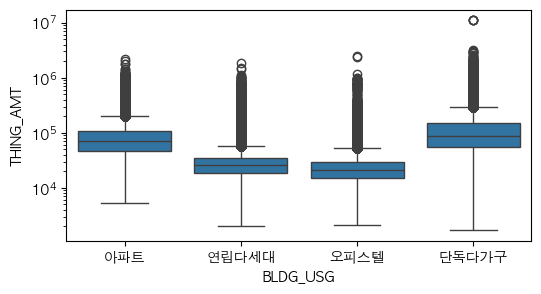

In [168]:
# THING_AMT 이상치/범위 확인
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize=(6,3))
sns.boxplot(data=df2, x='BLDG_USG', y='THING_AMT')
plt.yscale('log')
plt.show()

In [169]:
df2['THING_AMT'].describe()

count    8.336130e+05
mean     6.424754e+04
std      7.515893e+04
min      1.700000e+03
25%      2.450000e+04
50%      4.200000e+04
75%      8.000000e+04
max      1.108778e+07
Name: THING_AMT, dtype: float64

In [170]:
floor_price = floor_df.loc[floor_df['FLR']<=0,['FLR','THING_AMT']]
floor_price.describe()

,FLR,THING_AMT
count,78722.000000,7.872200e+04
mean,-0.270407,1.005797e+05
std,0.446057,1.568377e+05
min,-3.000000,1.700000e+03
25%,-1.000000,2.600000e+04
50%,0.000000,6.400000e+04
75%,0.000000,1.200000e+05
max,0.000000,1.108778e+07


In [171]:
print(floor_price)

        FLR  THING_AMT
11     -1.0      11000
14      0.0      73000
16      0.0     102000
43      0.0      88700
87      0.0      95000
...     ...        ...
833396  0.0     520000
833579  0.0      23000
833591 -1.0      10500
833612  0.0     195000
833613  0.0     164000

[78722 rows x 2 columns]


# 컬럼명을 직접 지정하며 변환 (예: 층, 빈도수)
floor_df = df2['FLR'].value_counts().sort_index().reset_index()
floor_df.columns = ['FLR', 'count']

print(floor_df)

In [172]:
# 지역별 지하 층 보유 세대의 핵심 컬럼과 카운트
target_cols = ['CGG_NM','STDG_NM','FLR','ARCH_YR','BLDG_USG']
floor_df_cnt = floor_df.loc[floor_df['FLR'] < 0,target_cols].value_counts().sort_index().reset_index()
floor_df_cnt.columns = target_cols + ['count']

floor_df_cnt.to_csv('data/floor_df.csv', index=False, encoding='cp949')
floor_df_cnt
# floor_df = pd.read_csv('data/floor_df.csv', encoding='cp949')
# print(floor_df)

,CGG_NM,STDG_NM,FLR,ARCH_YR,BLDG_USG,count
0,강남구,개포동,-1.0,1986.0,연립다세대,1
1,강남구,개포동,-1.0,1987.0,연립다세대,3
2,강남구,개포동,-1.0,1988.0,연립다세대,4
3,강남구,개포동,-1.0,1989.0,연립다세대,10
4,강남구,개포동,-1.0,1990.0,연립다세대,7
...,...,...,...,...,...,...
2570,중랑구,중화동,-1.0,1996.0,연립다세대,7
2571,중랑구,중화동,-1.0,1997.0,연립다세대,6
2572,중랑구,중화동,-1.0,2002.0,연립다세대,1
2573,중랑구,중화동,-1.0,2003.0,아파트,1


In [173]:
temp = df2.loc[(df2['STDG_NM']=='화곡동') & (df2['FLR']<0)]
temp

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
11,11500,강서구,10300,화곡동,진보빌라,2018-12-31,11000,55.99,27.49,-1.0,NaN,NaN,2001.0,연립다세대,NaN
550,11500,강서구,10300,화곡동,승윤맨션,2018-12-21,9900,64.86,32.48,-1.0,NaN,NaN,2002.0,연립다세대,NaN
1824,11500,강서구,10300,화곡동,대호아트타운가동,2018-12-07,7000,39.70,20.15,-1.0,NaN,NaN,1992.0,연립다세대,NaN
2068,11500,강서구,10300,화곡동,라이프주택,2018-12-05,8200,43.20,28.75,-1.0,NaN,NaN,1986.0,연립다세대,NaN
2549,11500,강서구,10300,화곡동,대주쉐르빌(338-9),2018-12-01,5000,30.38,14.00,-1.0,NaN,NaN,2002.0,연립다세대,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832213,11500,강서구,10300,화곡동,태경하이츠(343-29),2023-12-28,15800,65.18,32.09,-1.0,NaN,NaN,2000.0,연립다세대,직거래
832305,11500,강서구,10300,화곡동,남경베스트빌(C동),2023-12-27,12000,41.65,19.87,-1.0,NaN,NaN,2001.0,연립다세대,중개거래
832624,11500,강서구,10300,화곡동,성지빌라(29-91),2023-12-23,11000,36.90,25.02,-1.0,NaN,NaN,1997.0,연립다세대,중개거래
832716,11500,강서구,10300,화곡동,성도그린빌라,2023-12-21,17300,60.64,28.26,-1.0,NaN,NaN,2001.0,연립다세대,중개거래


In [174]:
# 1. 빈도수 계산 후 데이터프레임 변환
arch_yr_cnt = df2['ARCH_YR'].value_counts().reset_index()

# 2. 컬럼명 알기 쉽게 변경 (연도, 개수)
arch_yr_cnt.columns = ['ARCH_YR', 'count']

# 3. count 컬럼 기준 내림차순(desc) 정렬
arch_yr_cnt = arch_yr_cnt.sort_values(by='count', ascending=False)

print(arch_yr_cnt)

     ARCH_YR  count
0     2003.0  37091
1     2004.0  35162
2     2002.0  34972
3     2016.0  27124
4     2015.0  24507
..       ...    ...
105   1927.0      2
106   1926.0      1
107   1909.0      1
108   1922.0      1
109    970.0      1

[110 rows x 2 columns]


In [175]:
price_bldg = df2.groupby('BLDG_USG')['THING_AMT'].mean()

In [ ]:
df = pd.read_csv

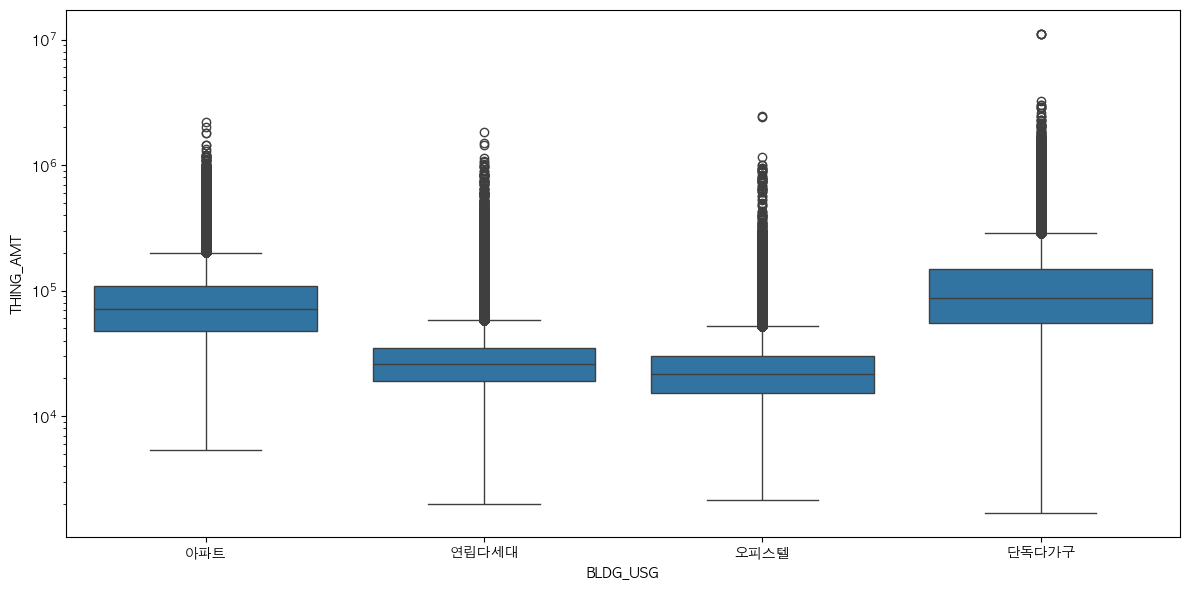

In [176]:
# 건물용도별 이상치 확인
import matplotlib.pyplot as plt 
import seaborn as sns 
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

plt.figure(figsize=(12,6))
sns.boxplot(data=df2, x='BLDG_USG', y='THING_AMT')
plt.yscale('log') # 범위가 너무 넓어서 로그스케일 사용
plt.tight_layout() 
plt.show()

In [177]:
df2[df2['BLDG_USG']=='아파트'].describe()

,CGG_CD,STDG_CD,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RTRCN_DAY,ARCH_YR
count,393388.000000,393388.000000,393388,3.933880e+05,393388.000000,228598.0,393388.000000,8.598000e+03,393386.000000
mean,11454.832837,10939.269881,2020-09-17 01:14:40.022776576,8.857776e+04,76.604500,0.0,9.365985,2.021818e+07,1962.500508
min,11110.000000,10100.000000,2008-06-15 00:00:00,5.400000e+03,10.020000,0.0,-3.000000,2.020022e+07,0.000000
25%,11320.000000,10300.000000,2019-03-23 00:00:00,4.750000e+04,59.670000,0.0,4.000000,2.020102e+07,1994.000000
50%,11470.000000,10600.000000,2020-05-20 00:00:00,7.100000e+04,81.450000,0.0,8.000000,2.021121e+07,2001.000000
75%,11590.000000,10900.000000,2021-10-08 00:00:00,1.090000e+05,84.970000,0.0,13.000000,2.023093e+07,2008.000000
max,11740.000000,18700.000000,2024-10-14 00:00:00,2.200000e+06,395.060000,0.0,73.000000,2.024101e+07,2024.000000
std,174.459365,1204.007947,NaN,6.702831e+04,30.645141,0.0,6.338936,1.537121e+04,275.879632


<class 'pandas.core.frame.DataFrame'>
Index: 393388 entries, 0 to 833606
Data columns (total 15 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   CGG_CD     393388 non-null  int64         
 1   CGG_NM     393388 non-null  object        
 2   STDG_CD    393388 non-null  int64         
 3   STDG_NM    393388 non-null  object        
 4   BLDG_NM    393388 non-null  object        
 5   CTRT_DAY   393388 non-null  datetime64[ns]
 6   THING_AMT  393388 non-null  int64         
 7   ARCH_AREA  393388 non-null  float64       
 8   LAND_AREA  228598 non-null  float64       
 9   FLR        393388 non-null  float64       
 10  RGHT_SE    7613 non-null    object        
 11  RTRCN_DAY  8598 non-null    float64       
 12  ARCH_YR    393386 non-null  float64       
 13  BLDG_USG   393388 non-null  object        
 14  DCLR_SE    96733 non-null   object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(6)
memory usage: 48.0+

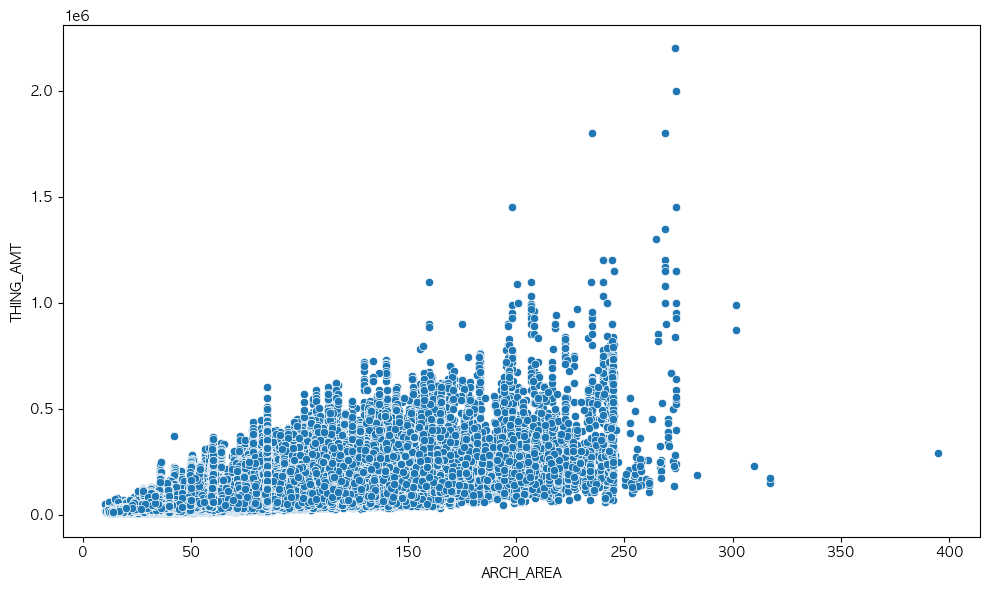

In [178]:
# 아파트
apt = df2[df2['BLDG_USG']=='아파트']
apt.info()

plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

In [179]:
apt['ARCH_AREA'].describe()
''' 
count    393388.000000
mean         76.604500
std          30.645141
min          10.020000
25%          59.670000
50%          81.450000
75%          84.970000
max         395.060000
Name: ARCH_AREA, dtype: float64
'''

' \ncount    393388.000000\nmean         76.604500\nstd          30.645141\nmin          10.020000\n25%          59.670000\n50%          81.450000\n75%          84.970000\nmax         395.060000\nName: ARCH_AREA, dtype: float64\n'

In [180]:
apt['THING_AMT'].describe()
''' 
count    3.933880e+05
mean     8.857776e+04
std      6.702831e+04
min      5.400000e+03
25%      4.750000e+04
50%      7.100000e+04
75%      1.090000e+05
max      2.200000e+06 # 220억
Name: THING_AMT, dtype: float64 
'''

' \ncount    3.933880e+05\nmean     8.857776e+04\nstd      6.702831e+04\nmin      5.400000e+03\n25%      4.750000e+04\n50%      7.100000e+04\n75%      1.090000e+05\nmax      2.200000e+06 # 220억\nName: THING_AMT, dtype: float64 \n'

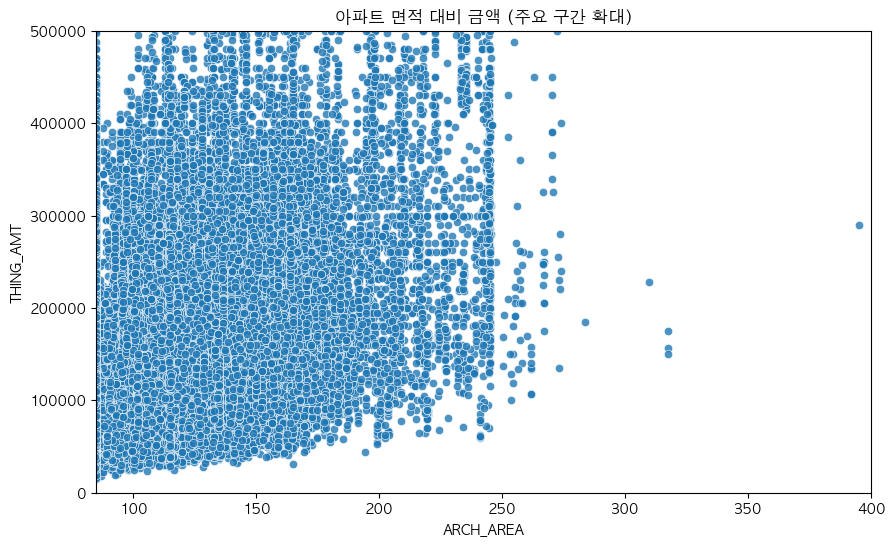

In [181]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

area_q3 = apt['ARCH_AREA'].quantile(0.75)
# x축: q3 ~ 400 (건물면적 최댓값이 395)
# y축: 금액 50억(500,000만원) 이하로 제한
plt.xlim(area_q3,400)
plt.ylim(0, 0.5e+06)

plt.title('아파트 면적 대비 금액 (주요 구간 확대)')
plt.show()

In [182]:
apt[apt['ARCH_AREA']>300]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
8974,11170,용산구,12900,이촌동,정우,2018-10-26,157000,317.36,NaN,5.0,NaN,NaN,1972.0,아파트,NaN
17365,11650,서초구,10800,서초동,월드빌라트,2018-09-28,290000,395.06,NaN,10.0,NaN,NaN,1996.0,아파트,NaN
373613,11170,용산구,12900,이촌동,정우,2020-07-04,150000,317.36,0.0,2.0,NaN,NaN,1972.0,아파트,NaN
556901,11170,용산구,12900,이촌동,정우,2021-05-13,175000,317.36,0.0,9.0,NaN,NaN,1972.0,아파트,NaN
654248,11680,강남구,11800,도곡동,타워팰리스1,2022-05-12,870000,301.47,0.0,56.0,NaN,NaN,2002.0,아파트,중개거래
713369,11680,강남구,11800,도곡동,타워팰리스1,2023-07-31,990000,301.47,0.0,55.0,NaN,NaN,2002.0,아파트,중개거래
743250,11140,중구,14300,장충동1가,장충레지던스,2023-03-16,228000,309.70,0.0,4.0,NaN,NaN,1993.0,아파트,직거래


In [183]:
### 정우 ---> 이상치 x
# 유형 아파트
# 세대수 24세대
# 동수 총 1동
# 사용승인일 1972.05.01
# 면적 287.04㎡ ~ 353.12㎡
# 매매가 25억

In [184]:
### 월드 빌라트 ---> 이상치 x
# 유형 아파트
# 세대수 19세대
# 동수 총 1동
# 사용승인일 1996.12.31
# 면적 281.06㎡ ~ 453.71㎡
# 매매가 40억~85억

In [185]:
### 장충 레지던스 ---> 이상치 x
# 매매가 19억~22억

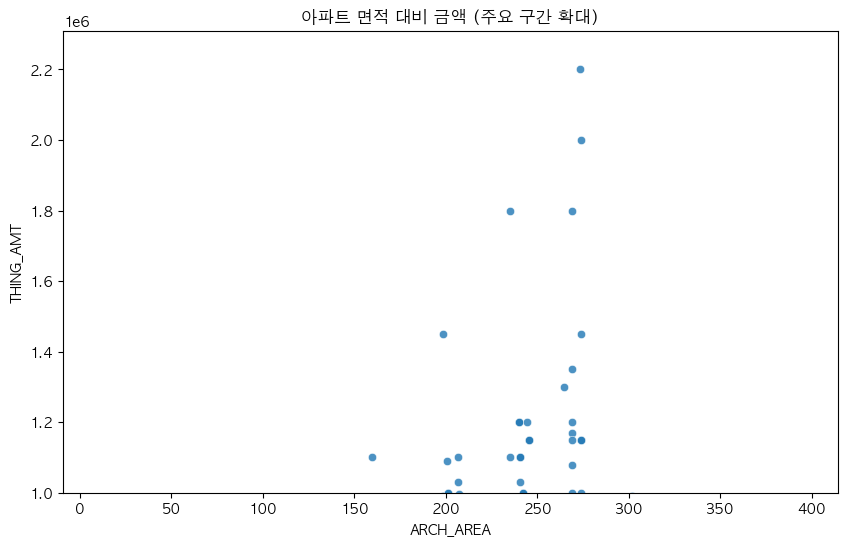

In [186]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=apt, x='ARCH_AREA', y='THING_AMT', alpha=0.8) # alpha로 겹친 점 확인

# y축: 금액 100억(1,000,000만원) 이상
# plt.xlim(area_q3,400)
plt.ylim(1.0e+06,)

plt.title('아파트 면적 대비 금액 (주요 구간 확대)')
plt.show()

아파튼데 100억이 넘어???

In [188]:
# 가격이 높게 형성된 매물 확인
high_price = apt.loc[apt['THING_AMT']>=1.0e+06,['CTRT_YEAR','STDG_NM','BLDG_NM','THING_AMT','ARCH_AREA','FLR','DCLR_SE']]
high_price

KeyError: "['CTRT_YEAR'] not in index"

In [ ]:
# 파르크한남 
# 면적 320A
# 가격 180억 (직거래의 경우 135억)

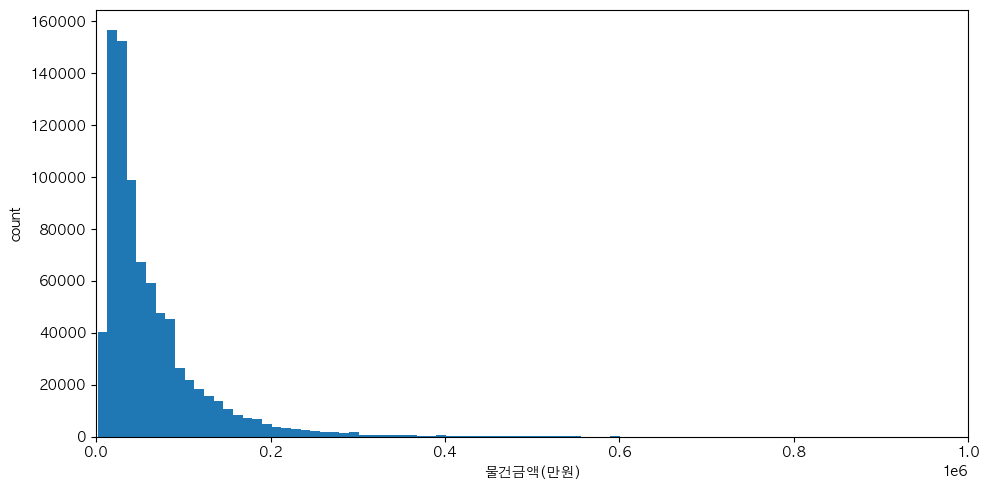

In [ ]:
# 건물가격 비율 분포 확인 
plt.figure(figsize=(10,5))
plt.hist(df_org['물건금액(만원)'], bins = 1000)
plt.xlabel('물건금액(만원)')
plt.ylabel('count')
plt.xlim(0,0.1e+07)
plt.tight_layout() 
plt.show()

평당 6000만원

In [ ]:
# 면적 대비 가격 비율 확인
df_org['ratio'] = df_org['물건금액(만원)'] / df_org['건물면적(㎡)']
df_org['ratio'].describe()

count    833614.000000
mean        922.854023
std         586.646150
min          23.871286
25%         540.305011
50%         779.132791
75%        1121.653677
max        9859.154930
Name: ratio, dtype: float64

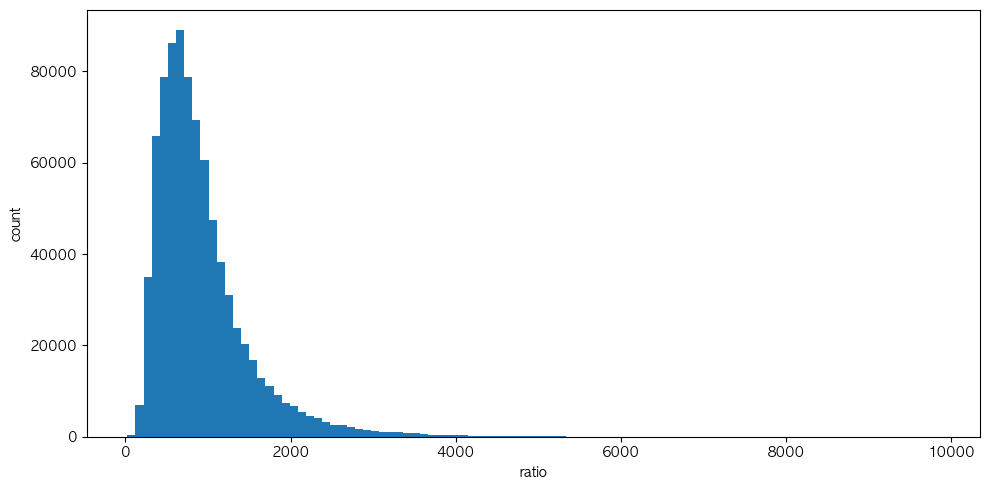

In [ ]:
# 면적 대비 가격 비율 분포 확인 
plt.figure(figsize=(10,5))
plt.hist(df_org['ratio'], bins = 100)
plt.xlabel('ratio')
plt.ylabel('count')
plt.tight_layout() 
plt.show()

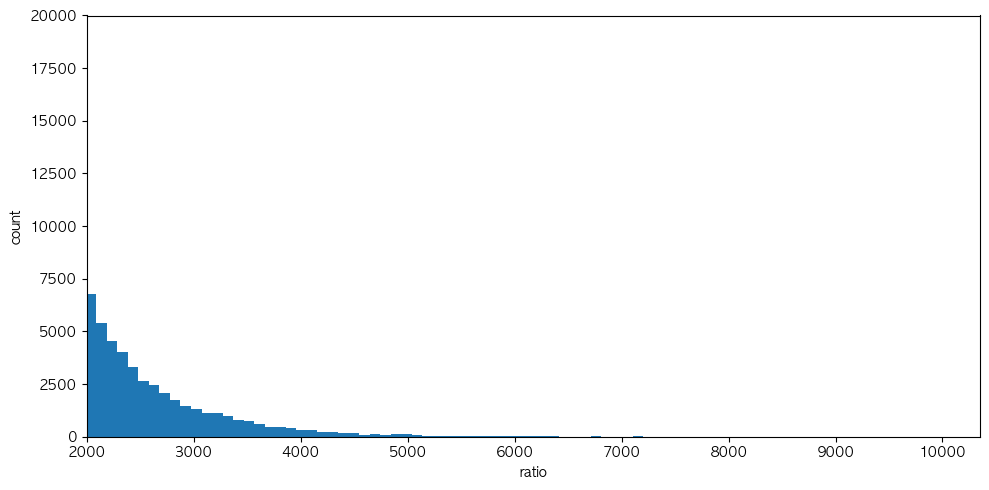

In [ ]:
# 면적 대비 가격 비율 분포 확인 
plt.figure(figsize=(10,5))
plt.hist(df_org['ratio'], bins = 100)
plt.xlabel('ratio')
plt.ylabel('count')
plt.xlim(2000,)
plt.ylim(0,20000)
plt.tight_layout() 
plt.show()

In [ ]:
# 직거래 데이터 확인
jik = df_org.loc[df_org['신고구분'] == '직거래']
# 면적 대비 가격 비율 확인
jik['ratio'] = jik['물건금액(만원)'] / jik['건물면적(㎡)']
jik['ratio'].describe()

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/786979528.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  jik['ratio'] = jik['물건금액(만원)'] / jik['건물면적(㎡)']


count    41302.000000
mean       983.470968
std        529.216381
min         62.658931
25%        685.907046
50%        934.033859
75%       1180.367748
max       9687.840290
Name: ratio, dtype: float64

In [ ]:
# 직거래 경우 토지면적 확인
jik['토지면적(㎡)'].info()

<class 'pandas.core.series.Series'>
Index: 41302 entries, 481300 to 833603
Series name: 토지면적(㎡)
Non-Null Count  Dtype  
--------------  -----  
41038 non-null  float64
dtypes: float64(1)
memory usage: 645.3 KB


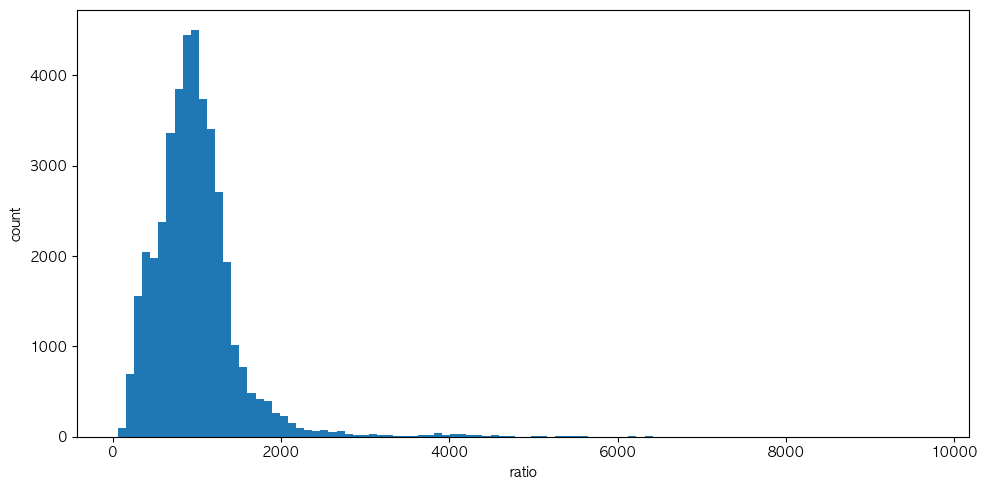

In [ ]:
# 직거래 경우 면적 대비 가격 비율 분포 확인 
plt.figure(figsize=(10,5))
plt.hist(jik['ratio'], bins = 100)
plt.xlabel('ratio')
plt.ylabel('count')
plt.tight_layout() 
plt.show()

In [ ]:
df_org.loc[(df_org['건물면적(㎡)']>300) & (df_org['건물용도']=='아파트')]

,접수연도,자치구코드,자치구명,법정동코드,법정동명,지번구분,지번구분명,본번,부번,건물명,...,건물면적(㎡),토지면적(㎡),층,권리구분,취소일,건축년도,건물용도,신고구분,신고한_개업공인중개사_시군구명,ratio
8974,2018,11170,용산구,12900,이촌동,1.0,대지,302.0,69.0,정우,...,317.36,NaN,5.0,NaN,NaN,1972.0,아파트,NaN,NaN,494.706327
17365,2018,11650,서초구,10800,서초동,1.0,대지,1518.0,2.0,월드빌라트,...,395.06,NaN,10.0,NaN,NaN,1996.0,아파트,NaN,NaN,734.065712
373613,2020,11170,용산구,12900,이촌동,1.0,대지,302.0,69.0,정우,...,317.36,0.0,2.0,NaN,NaN,1972.0,아파트,NaN,NaN,472.649357
556901,2021,11170,용산구,12900,이촌동,1.0,대지,302.0,69.0,정우,...,317.36,0.0,9.0,NaN,NaN,1972.0,아파트,NaN,NaN,551.424250
654248,2022,11680,강남구,11800,도곡동,1.0,대지,467.0,0.0,타워팰리스1,...,301.47,0.0,56.0,NaN,NaN,2002.0,아파트,중개거래,서울 강남구,2885.859289
713369,2023,11680,강남구,11800,도곡동,1.0,대지,467.0,0.0,타워팰리스1,...,301.47,0.0,55.0,NaN,NaN,2002.0,아파트,중개거래,서울 강남구,3283.908847
743250,2023,11140,중구,14300,장충동1가,1.0,대지,106.0,1.0,장충레지던스,...,309.70,0.0,4.0,NaN,NaN,1993.0,아파트,직거래,NaN,736.196319


In [ ]:
apt[apt['FLR']<0]

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
13345,11170,용산구,13100,한남동,한남더힐,2018-10-10,630000,240.23,NaN,-1.0,NaN,NaN,2011.0,아파트,NaN
23872,11110,종로구,17500,숭인동,동문타운,2018-09-10,31300,59.56,NaN,-1.0,NaN,NaN,2000.0,아파트,NaN
38464,11380,은평구,11400,진관동,우물골2단지두산위브(223~244동)BL2-7,2018-08-23,76000,134.48,0.0,-2.0,NaN,NaN,2010.0,아파트,NaN
53268,11440,마포구,10800,대흥동,성신,2018-08-02,44000,75.06,NaN,-1.0,NaN,NaN,2006.0,아파트,NaN
55844,11170,용산구,13100,한남동,한성1,2018-07-28,45000,65.16,NaN,-1.0,NaN,NaN,1974.0,아파트,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779209,11200,성동구,11300,옥수동,옥수파크힐스101동~116동,2024-07-15,202000,76.66,0.0,-2.0,NaN,NaN,2016.0,아파트,중개거래
795210,11140,중구,16200,신당동,토토타워(5차),2024-06-04,17800,59.94,0.0,-1.0,NaN,NaN,2001.0,아파트,중개거래
805012,11200,성동구,11300,옥수동,옥수파크힐스101동~116동,2024-05-01,199000,76.66,0.0,-2.0,NaN,NaN,2016.0,아파트,중개거래
810315,11170,용산구,13100,한남동,한남더힐,2024-04-10,1200000,240.23,NaN,-2.0,NaN,20240507.0,2011.0,아파트,중개거래


In [ ]:
# 평수는 넓은데 가격이 적은 이상한 데이터 확인
area_q3 = apt['ARCH_AREA'].quantile(0.75)
amt_q1 = apt['THING_AMT'].quantile(0.25)
weird_apt = apt.loc[(apt['ARCH_AREA']>area_q3) & (apt['THING_AMT']<amt_q1)]
weird_apt

,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,RTRCN_DAY,ARCH_YR,BLDG_USG,DCLR_SE
61,11320,도봉구,10600,방학동,우성아파트2,2018-12-28,37000,84.98,NaN,2.0,NaN,NaN,1993.0,아파트,NaN
66,11260,중랑구,10600,신내동,새한,2018-12-28,42000,115.84,NaN,23.0,NaN,NaN,1998.0,아파트,NaN
443,11290,성북구,11300,삼선동3가,유니아테라스,2018-12-22,38000,91.70,NaN,4.0,NaN,NaN,2003.0,아파트,NaN
682,11545,금천구,10300,시흥동,벽산,2018-12-20,38000,114.84,NaN,2.0,NaN,NaN,2000.0,아파트,NaN
686,11380,은평구,10800,역촌동,디딤빌아파트,2018-12-20,37000,126.00,NaN,4.0,NaN,NaN,2000.0,아파트,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
829486,11500,강서구,10200,등촌동,등촌동성원,2024-01-15,45600,99.29,0.0,5.0,NaN,NaN,1997.0,아파트,직거래
829492,11500,강서구,10300,화곡동,화곡한강,2024-01-15,41500,88.95,0.0,1.0,NaN,NaN,2007.0,아파트,중개거래
829504,11500,강서구,10200,등촌동,등촌동성원,2024-01-15,45600,99.29,NaN,5.0,NaN,20240314.0,1997.0,아파트,직거래
830078,11320,도봉구,10600,방학동,벽산아파트2,2024-01-12,46800,84.98,0.0,3.0,NaN,NaN,1998.0,아파트,중개거래


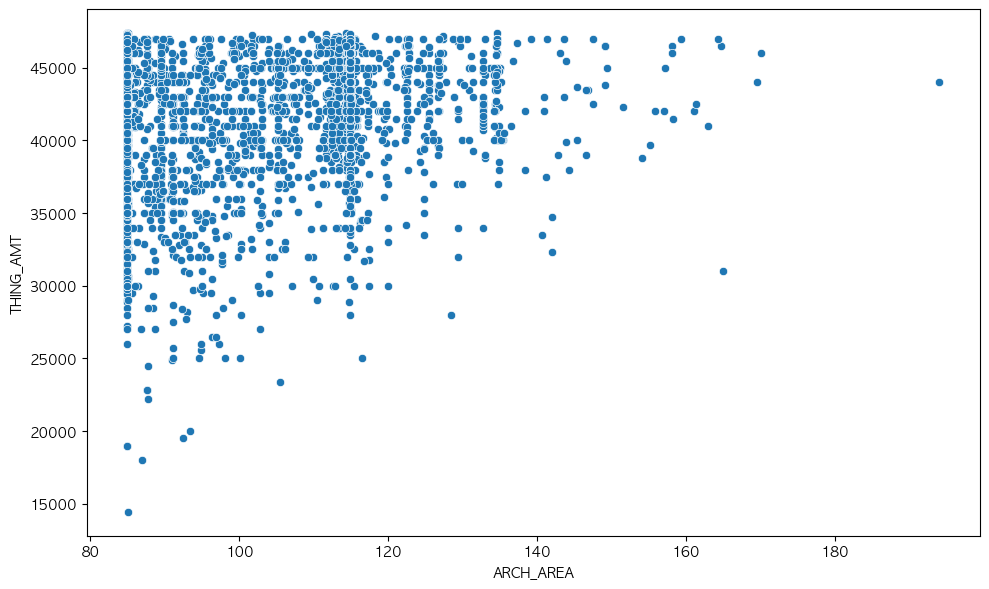

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=weird_apt, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

<class 'pandas.core.frame.DataFrame'>
Index: 2101 entries, 1742 to 833144
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   CGG_CD     2101 non-null   int64         
 1   CGG_NM     2101 non-null   object        
 2   STDG_CD    2101 non-null   int64         
 3   STDG_NM    2101 non-null   object        
 4   BLDG_NM    2101 non-null   object        
 5   CTRT_DAY   2101 non-null   datetime64[ns]
 6   THING_AMT  2101 non-null   int64         
 7   ARCH_AREA  2101 non-null   float64       
 8   LAND_AREA  1216 non-null   float64       
 9   FLR        2101 non-null   float64       
 10  RGHT_SE    4 non-null      object        
 11  RTRCN_DAY  80 non-null     float64       
 12  ARCH_YR    2101 non-null   float64       
 13  BLDG_USG   2101 non-null   object        
 14  DCLR_SE    447 non-null    object        
dtypes: datetime64[ns](1), float64(5), int64(3), object(6)
memory usage: 262.6+ KB


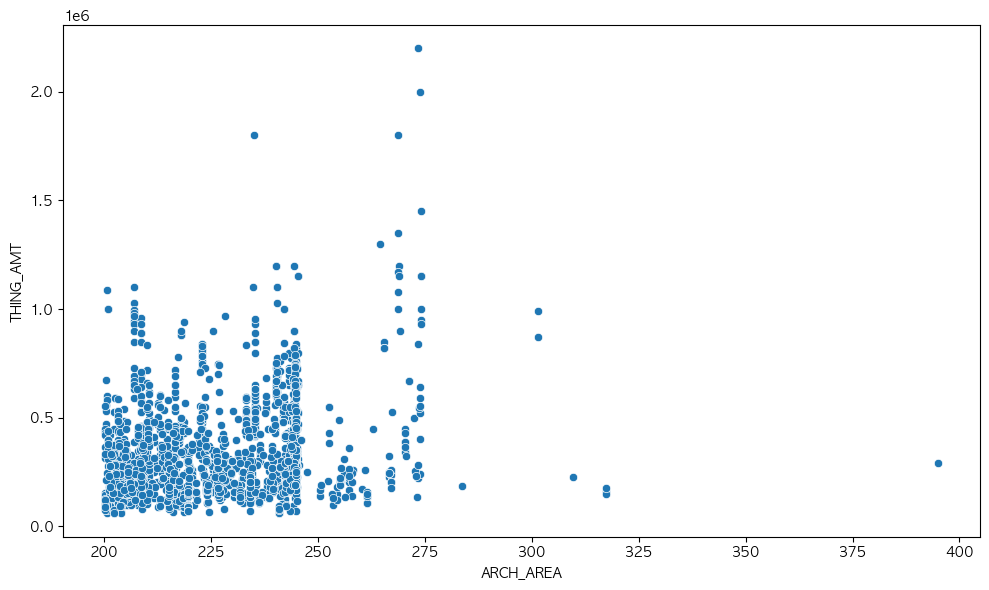

In [ ]:
# 큰 평수 아파트 
big_apt = apt[apt['ARCH_AREA']>200]
big_apt.info() 

plt.figure(figsize=(10,6))
sns.scatterplot(data=big_apt, x='ARCH_AREA', y='THING_AMT')
plt.tight_layout() 
plt.show()

In [192]:
apt['ARCH_YR'].isna().sum()

np.int64(2)

In [191]:
apt['ARCH_YR'].value_counts()

ARCH_YR
2004.0    20361
2003.0    19951
1999.0    19236
2000.0    18314
1988.0    17256
          ...  
2024.0       57
1961.0       26
1966.0       19
1967.0        7
1965.0        5
Name: count, Length: 62, dtype: int64

In [193]:
df2 = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_55181/3277024107.py:1: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')


In [195]:
df2[(df2['ARCH_YR']==0) & (df2['RGHT_SE'].isna())]

,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
72624,72626,11140,중구,16200,신당동,NaN,2018-06-15,39000,92.56,46.0,NaN,NaN,0,단독다가구,NaN,2018
596303,624457,11140,중구,14400,장충동2가,NaN,2022-11-10,66600,79.34,69.4,NaN,NaN,0,단독다가구,중개거래,2022
605381,634339,11170,용산구,12800,한강로3가,NaN,2022-08-17,300000,62.58,139.5,NaN,NaN,0,단독다가구,중개거래,2022
667076,700063,11500,강서구,10900,방화동,NaN,2023-09-26,137000,132.28,152.0,NaN,NaN,0,단독다가구,중개거래,2023
707341,742464,11710,송파구,11400,마천동,NaN,2023-03-20,140000,437.21,179.4,NaN,NaN,0,단독다가구,중개거래,2023
